In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from utils.plots import *
from rl.models import Tonic_DA_model

warnings.filterwarnings("ignore")
rseed =10
np.random.seed(rseed)

## Tonic Dopamine model

This notebook performs the basic predictions of the tonic Dopamine model proposed in the manuscript:  *Romero Pinto, S., & Uchida, N. (2023). **Tonic dopamine and biases in value learning linked through a biologically inspired reinforcement learning model***

**Note:** No data is needed for this notebook


In [2]:
md = Tonic_DA_model()
DA = md.DA
ec50_1 = md.ec50_1
ec50_2 = md.ec50_2
delta_DA = md.delta_DA
slope_D1_log, slope_D2_log = md.compute_sensitivities(type_scale='log')
taus_log = md.compute_taus(type_scale='log')
slope_D1_lin, slope_D2_lin = md.compute_sensitivities(type_scale='lin')
taus_lin = md.compute_taus(type_scale='lin')
occ_D1, occ_D2, DA_occ =md.compute_dose_occupancy(DA_range = [-2,6])
colorD1 = 'deepskyblue'
colorD2 = 'hotpink'

### Figure 2b
Dose-occupancy curves for the D1R and D2R describing receptor occupancies as a function of dopamine concentrations

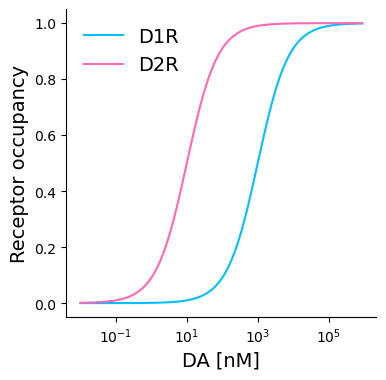

In [3]:
fig, ax = plt.subplots(figsize = (4,4))
ax.semilogx(DA_occ,occ_D1,color=colorD1,linewidth=1.5,label='D1R')
ax.semilogx(DA_occ,occ_D2,color=colorD2,linewidth=1.5,label='D2R')
plot_config(ax,'DA [nM]','Receptor occupancy',14,True)

### Figure 3a

This figure illustreates the mechanism by which increases or decreases in baseline dopamine modulates the degree to which bursts and pauses in dopamine causes changes in D1R and D2R occupancy.
- **Increases** in baseline dopamine makes dopamine pauses to cause greater decreases in D2R occupancy than the increases in D1R occupancy caused by dopamine bursts (blue). 
- **Decreases** in dopamine, makes dopamine bursts to cause smaller increases in D1R occupancy than the decreases in D2R occupancy caused by dopamine pauses (red).

[None, None, None]

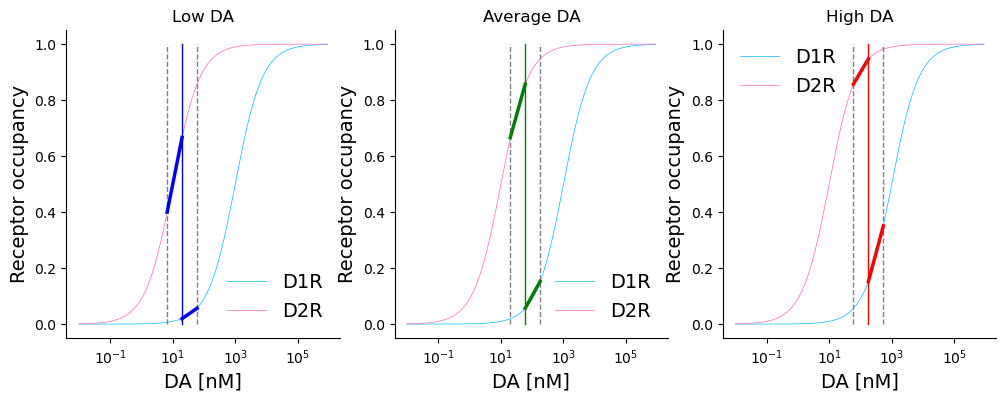

In [4]:
DA_levels = np.asarray([60/3,60,60*3])
color_levels = ['blue','green','red']
tit_levels = ['Low DA','Average DA','High DA']

fig, ax = plt.subplots(1,3,figsize = (12,4))
[ia.semilogx(DA_occ,occ_D1,color=colorD1,linewidth=.5,label='D1R') for ia in ax]
[ia.semilogx(DA_occ,occ_D2,color=colorD2,linewidth=.5,label='D2R') for ia in ax]

[ia.plot([c, c],[0, 1],color = cl,linewidth=1) for (c,ia,cl) in zip(DA_levels,ax,color_levels)]
[ia.plot([c*delta_DA, c*delta_DA],[0, 1],color = 'grey',linestyle='--',linewidth=1) for (c,ia,cl) in zip(DA_levels,ax,color_levels)]
[ia.plot([c/delta_DA, c/delta_DA],[0, 1],color = 'grey',linestyle='--',linewidth=1) for (c,ia,cl) in zip(DA_levels,ax,color_levels)]

dDA_neg,dDA_pos = DA_levels/delta_DA, DA_levels*delta_DA
D2_levels, D1_levels = DA_levels/(DA_levels+ec50_2),DA_levels/(DA_levels+ec50_1)
dD2_levels, dD1_levels = dDA_neg/(dDA_neg+ec50_2),dDA_pos/(dDA_pos+ec50_1)

[ia.plot([c,dc],[r,dr] ,color=cl,linewidth=2.5)  for (ia,c,dc,r,dr,cl) in zip(ax,DA_levels,dDA_neg,D2_levels,dD2_levels,color_levels)]
[ia.plot([c,dc],[r,dr] ,color=cl,linewidth=2.5)  for (ia,c,dc,r,dr,cl) in zip(ax,DA_levels,dDA_pos,D1_levels,dD1_levels,color_levels)]

[plot_config(ia,'DA [nM]','Receptor occupancy',14,True) for ia in ax]
[title_(ia,tit) for (ia,tit) in zip(ax,tit_levels)]

### Figure 3c

Receptor sensitivity for D1R and D2R as a function of baseline dopamine. 

In Model 1 in the manuscript, we assume that the receptor sensitivity acts as a scaling factor on the PKA activity induced by burst and pauses.
That is:

$PKA_{D1} \propto \alpha_{D1} \cdot \delta \cdot \textbf{1}_{\delta>0}$ , where $ \alpha_{D1}$ is the receptor sensitivity for D1R

$PKA_{D2} \propto \alpha_{D2} \cdot \delta \cdot \textbf{1}_{\delta<0}$ , where $ \alpha_{D2}$ is the receptor sensitivity for D2R

The figure below plots the normalized receptor sensitivities

Text(500, 0.4, '* D2R')

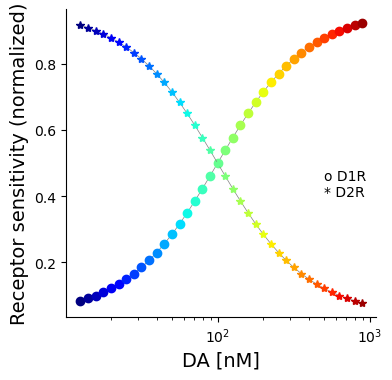

In [5]:
fig, ax = plt.subplots(figsize = (4,4))
ax.semilogx(DA,taus_log,color='grey',linewidth=.5)
_=[ax.semilogx(DA[ii],taus_log[ii],'o',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
ax.semilogx(DA,1-taus_log,color='grey',linewidth=.5)
_=[ax.semilogx(DA[ii],1-taus_log[ii],'*',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
plot_config(ax,'DA [nM]','Receptor sensitivity (normalized)',14,False)
ax.text(500,.45,'o D1R')
ax.text(500,.4,'* D2R')

### Extended data figure 9

The qualitative aspects of Model 1 are preserved irrespective of the assumption made about the changes in baseline dopamine caused by dopamine transients.  

Below are the computation of receptor sensitivities assuming logarithmic (left) or linear (middle) changes in baseline dopamine induced by dopamine transients (logΔDA,linΔDA, respectively). 
- The absolute magnitude of the slopes differs depending on the assumption made about the changes in baseline dopamine (logarithmic vs linear) but the asymmetric scaling factor presents only a small shift in the curve as a function of baseline dopamine (right). 
- The qualitative aspects of the model (i.e., non-monotonic relationship of the asymmetric scaling factor with baseline dopamine) is preserved regardless on this assumption.


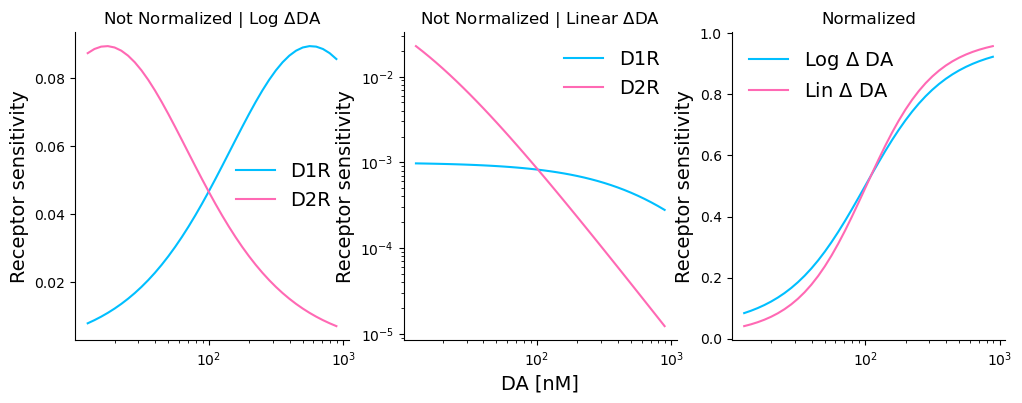

In [15]:
fig, ax = plt.subplots(1,3,figsize = (12,4))

ax[0].semilogx(DA,slope_D1_log,color=colorD1,linewidth=1.5, label= 'D1R')
ax[0].semilogx(DA,slope_D2_log,color=colorD2,linewidth=1.5, label = 'D2R')
plot_config(ax[0],'','Receptor sensitivity',14,True)
title_(ax[0],r'Not Normalized | Log $\Delta$DA')


ax[1].loglog(DA,slope_D1_lin,color=colorD1,linewidth=1.5, label= 'D1R')
ax[1].loglog(DA,slope_D2_lin,color=colorD2,linewidth=1.5, label = 'D2R')
plot_config(ax[1],'DA [nM]','Receptor sensitivity',14,True)
title_(ax[1],r'Not Normalized | Linear $\Delta$DA')

ax[2].semilogx(DA,taus_log,color=colorD1,linewidth=1.5, label= r'Log $\Delta$ DA')
ax[2].semilogx(DA,taus_lin,color=colorD2,linewidth=1.5, label =r'Lin $\Delta$ DA')
plot_config(ax[2],'','Receptor sensitivity',14,True)
title_(ax[2],r'Normalized')



### Closed form solutions for Value prediction

Below we compute the closed form solution for the value predictors for a Bernoulli distribution of rewards for Model 1 
Closed form solution is defined by: 

$$
V = \frac{\frac{\tau}{1-\tau}\cdot \frac{p}{1-p} \cdot r}{\frac{\tau}{1-\tau}\cdot \frac{p}{1-p} +1 +\frac{\beta}{(1-\tau)\cdot(1-p)}}
$$

where:
- $\tau$: asymmetric scaling factor (given by receptor sensitivity in Model 1)
- $p$: probability of reward in the Bernoulli distribution
- $r$: reward magnitude
- $\beta$: decay parameter in the update equation in Model 1

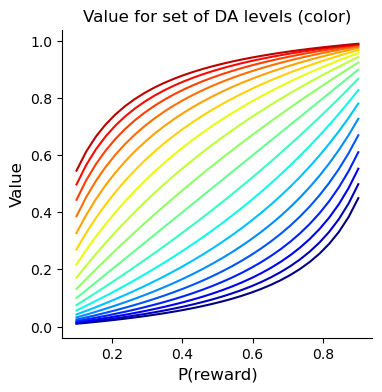

In [7]:

pv = np.linspace(0.1,0.9,30)
vs = np.asarray([md.compute_closed_form_bernoulli(p = p,r=1) for p in pv])
fig, ax = plt.subplots(figsize = (4,4))
_ = [ax.plot(pv,vs[:,ii],color=cm.jet(ii/vs.shape[1])) for  ii in np.arange(0,vs.shape[1],step=2)]
plot_config(ax,'P(reward)',r'Value ($\beta = $' + str(md.beta)+  ')',12,False)
title_(ax,'Value for set of DA levels (color)')